# Notebook 03: Paralelismo, Benchmarks y Patrones Avanzados

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/sonder-art/fdd_p26/blob/main/clase/16_computo/code/03_paralelismo_benchmarks.ipynb)

**Módulo 16 — Clase 3**

Este notebook acompaña los archivos `04b_asyncio_patrones.md`, `05_paralelismo.md`, `06_librerias_y_decision.md`.

Secciones **** se trabajan durante la sesión.  
Secciones **** se completan después.

---

In [15]:
import asyncio
import multiprocessing as mp
import time
import threading
import os
import sys
from concurrent.futures import ThreadPoolExecutor, ProcessPoolExecutor as _PPE


def process_pool_executor(max_workers=None, **kwargs):
    """ProcessPoolExecutor usable desde Jupyter en Linux/macOS.

    Con spawn/forkserver, los workers no pueden unpickle funciones definidas solo
    en celdas (__main__). Forzar contexto *fork* evita reimportar el módulo.
    """
    if max_workers is not None:
        kwargs['max_workers'] = max_workers
    if sys.platform != 'win32' and 'mp_context' not in kwargs:
        try:
            kwargs['mp_context'] = mp.get_context('fork')
        except ValueError:
            pass
    return _PPE(**kwargs)


print(f'Python {sys.version}')
print(f'CPU cores disponibles: {os.cpu_count()}')

Python 3.14.3 (main, Feb 17 2026, 19:22:15) [GCC 13.3.0]
CPU cores disponibles: 8


## Sección 1: create_task vs gather — trabajo intermedio "gratis"

**Hipótesis:** con `create_task`, podemos ejecutar trabajo independiente mientras una tarea espera.
El trabajo intermedio debe ocurrir "gratis" — durante el wait de la tarea lanzada.

In [3]:
async def tarea_io(nombre: str, duracion: float) -> str:
    """Simula I/O-bound: wait(τᵢ) ≠ ∅"""
    await asyncio.sleep(duracion)
    return f"{nombre} completada"

def trabajo_cpu_ligero(n: int) -> int:
    """Trabajo CPU-bound ligero: exec(τⱼ) mientras τᵢ espera"""
    return sum(range(n))

# --- Comparación: gather vs create_task ---

# gather: barrera — espera TODAS antes de continuar
print("=== gather: barrera ===")
t0 = time.perf_counter()
r1, r2 = await asyncio.gather(
    tarea_io("A", 1.0),
    tarea_io("B", 1.0),
)
t_gather = time.perf_counter() - t0
print(f"Resultados: {r1}, {r2}")
print(f"Tiempo: {t_gather:.2f}s (esperado ~1s)")
print()

# create_task: lanzar y continuar con trabajo intermedio
print("=== create_task + trabajo intermedio ===")
t0 = time.perf_counter()

# ① Lanzar τᵢ en background
tarea_a = asyncio.create_task(tarea_io("A", 1.0))

# ② Trabajo independiente DURANTE el wait de A
t_trabajo = time.perf_counter()
resultado_cpu = trabajo_cpu_ligero(5_000_000)   # ~200ms de CPU
t_trabajo = time.perf_counter() - t_trabajo
print(f"  Trabajo CPU completado en {t_trabajo:.2f}s (durante wait de A)")

# ③ Punto de dependencia: necesitamos el resultado de A
resultado_a = await tarea_a
t_create_task = time.perf_counter() - t0

print(f"  {resultado_a}")
print(f"Tiempo total: {t_create_task:.2f}s (esperado ~max(1s, tiempo_cpu))")
print()
print(f"Observa: el trabajo CPU ({t_trabajo:.2f}s) fue 'gratis' — ocurrió durante el wait de A.")
print(f"Sin create_task, hubiera sumado {1.0 + t_trabajo:.2f}s en lugar de {t_create_task:.2f}s")

=== gather: barrera ===
Resultados: A completada, B completada
Tiempo: 1.00s (esperado ~1s)

=== create_task + trabajo intermedio ===
  Trabajo CPU completado en 0.07s (durante wait de A)
  A completada
Tiempo total: 1.07s (esperado ~max(1s, tiempo_cpu))

Observa: el trabajo CPU (0.07s) fue 'gratis' — ocurrió durante el wait de A.
Sin create_task, hubiera sumado 1.07s en lugar de 1.07s


## Sección 2: as_completed — procesar resultados conforme llegan

Con tareas de **duración variable**, `gather` espera al más lento antes de procesar cualquier resultado.
`as_completed` permite procesar cada resultado tan pronto como está disponible.

In [4]:
import random

async def buscar_fuente(nombre: str, latencia: float) -> str:
    """Simula búsqueda en una fuente externa con latencia variable"""
    await asyncio.sleep(latencia)
    return f"resultado de {nombre} (tardó {latencia:.1f}s)"

fuentes = [
    ("Wikipedia", 0.5),
    ("ArXiv",     2.1),
    ("GitHub",    0.8),
    ("PubMed",    1.5),
    ("DuckDuck",  0.3),
]

# --- Con gather: espera el más lento ---
print("=== asyncio.gather: espera al más lento ===")
t0 = time.perf_counter()
resultados = await asyncio.gather(
    *[buscar_fuente(nombre, lat) for nombre, lat in fuentes]
)
t_gather = time.perf_counter() - t0
print(f"Todos los resultados disponibles a los {t_gather:.2f}s")
for r in resultados:
    print(f"  {r}")
print()

# --- Con as_completed: procesar conforme llegan ---
print("=== asyncio.as_completed: procesa conforme llegan ===")
t0 = time.perf_counter()
tareas = [asyncio.create_task(buscar_fuente(n, l)) for n, l in fuentes]

orden_llegada = []
async for tarea_completada in asyncio.as_completed(tareas):
    resultado = await tarea_completada
    t_llegada = time.perf_counter() - t0
    print(f"  t={t_llegada:.2f}s → {resultado}")
    orden_llegada.append(resultado)

print()
print("Observa: el orden de llegada es por latencia, no por orden de creación.")
print("El resultado más rápido (DuckDuck, 0.3s) llega primero aunque fue creado al final.")

=== asyncio.gather: espera al más lento ===
Todos los resultados disponibles a los 2.10s
  resultado de Wikipedia (tardó 0.5s)
  resultado de ArXiv (tardó 2.1s)
  resultado de GitHub (tardó 0.8s)
  resultado de PubMed (tardó 1.5s)
  resultado de DuckDuck (tardó 0.3s)

=== asyncio.as_completed: procesa conforme llegan ===
  t=0.31s → resultado de DuckDuck (tardó 0.3s)
  t=0.51s → resultado de Wikipedia (tardó 0.5s)
  t=0.81s → resultado de GitHub (tardó 0.8s)
  t=1.51s → resultado de PubMed (tardó 1.5s)
  t=2.11s → resultado de ArXiv (tardó 2.1s)

Observa: el orden de llegada es por latencia, no por orden de creación.
El resultado más rápido (DuckDuck, 0.3s) llega primero aunque fue creado al final.


---

## Sección 3: asyncio.Queue — productor-consumidor

Implementa el patrón productor-consumidor usando `asyncio.Queue`.

In [6]:
# TAREA 3: Implementar el patrón productor-consumidor
#
# Escenario: un productor genera 10 peticiones de chatbot a ritmo de 2/s.
# 3 workers las procesan (cada una tarda ~0.5s).
# Mide: ¿cuándo termina todo si hay 1, 2 o 3 workers?

N_PETICIONES = 10
RITMO_PRODUCCION = 0.5   # segundos entre peticiones (2/s)
T_PROCESAMIENTO = 0.5    # segundos que tarda cada petición

SENTINEL = None  # marca de fin para cada worker


async def productor(queue: asyncio.Queue, n: int, n_workers: int) -> None:
    # DONE: genera n peticiones y un sentinel por worker
    for i in range(n):
        await queue.put(f"petición-{i}")
        if i < n - 1:
            await asyncio.sleep(RITMO_PRODUCCION)
    for _ in range(n_workers):
        await queue.put(SENTINEL)


async def worker(queue: asyncio.Queue, nombre: str) -> None:
    # DONE: consume hasta sentinel
    while True:
        item = await queue.get()
        try:
            if item is SENTINEL:
                return
            await asyncio.sleep(T_PROCESAMIENTO)
        finally:
            queue.task_done()


async def ejecutar_con_workers(n_workers: int) -> float:
    # DONE: gather productor + workers y devuelve tiempo total
    q: asyncio.Queue = asyncio.Queue()
    t0 = time.perf_counter()
    await asyncio.gather(
        productor(q, N_PETICIONES, n_workers),
        *[worker(q, f"worker-{k}") for k in range(n_workers)],
    )
    return time.perf_counter() - t0


# DONE: mide con 1, 2 y 3 workers
for nw in (1, 2, 3):
    t = await ejecutar_con_workers(nw)
    print(f"Workers={nw}: tiempo total hasta terminar todo ≈ {t:.2f}s")

print()
print("Con más workers, el procesamiento en paralelo reduce la cola; el productor sigue")
print("inyectando a 2/s, así que el cuello de botella cambia entre producción y servicio.")

Workers=1: tiempo total hasta terminar todo ≈ 5.04s
Workers=2: tiempo total hasta terminar todo ≈ 5.04s
Workers=3: tiempo total hasta terminar todo ≈ 5.04s

Con más workers, el procesamiento en paralelo reduce la cola; el productor sigue
inyectando a 2/s, así que el cuello de botella cambia entre producción y servicio.


## Sección 4: fire-and-forget — excepción silenciada vs tracked

In [7]:
# TAREA 4: Demostrar fire-and-forget con excepción silenciada

async def tarea_que_falla():
    await asyncio.sleep(0.1)
    raise ValueError("¡Error en la tarea!")

# Anti-patrón: fire-and-forget sin tracking
print("=== Anti-patrón: fire-and-forget ===")
t = asyncio.create_task(tarea_que_falla())   # ← lanza la tarea
await asyncio.sleep(0.5)                      # ← la excepción ocurre, pero...
print("No se vio ningún error — ¡la excepción fue silenciada!")
# Nota: Python puede mostrar una advertencia al final, pero no interrumpe el programa
print()

# DONE: patrón correcto con callback que registra errores
def log_excepcion_si_hay(fut: asyncio.Task) -> None:
    try:
        exc = fut.exception()
        if exc is not None:
            print(f"[done_callback] Tarea falló: {type(exc).__name__}: {exc}")
    except asyncio.CancelledError:
        pass


print("=== Con add_done_callback (tracking) ===")
t2 = asyncio.create_task(tarea_que_falla())
t2.add_done_callback(log_excepcion_si_hay)
await asyncio.sleep(0.5)

=== Anti-patrón: fire-and-forget ===
No se vio ningún error — ¡la excepción fue silenciada!

=== Con add_done_callback (tracking) ===
[done_callback] Tarea falló: ValueError: ¡Error en la tarea!


## Sección 5: Benchmark asyncio vs threading — I/O-bound

Compara asyncio y ThreadPoolExecutor para tareas I/O-bound.
Ambos deberían funcionar — ¿cuál es más rápido y más simple?

In [8]:
import time
import requests  # síncrono
# import aiohttp  # si está disponible

# Simula I/O-bound síncrono (para ThreadPoolExecutor)
def io_bound_sync(duracion: float) -> str:
    time.sleep(duracion)   # simula requests.get, cursor.execute, etc.
    return "resultado"

N = 20
DUR = 0.2  # cada tarea tarda 0.2s

# --- ThreadPoolExecutor ---
t0 = time.perf_counter()
with ThreadPoolExecutor(max_workers=N) as pool:
    futuros = [pool.submit(io_bound_sync, DUR) for _ in range(N)]
    resultados = [f.result() for f in futuros]
t_thread = time.perf_counter() - t0
print(f"ThreadPoolExecutor ({N} workers): {t_thread:.2f}s  (esperado ~{DUR:.1f}s)")

# DONE: misma carga con asyncio.gather + asyncio.sleep (I/O no bloqueante en el hilo principal)
async def io_bound_async(duracion: float) -> str:
    await asyncio.sleep(duracion)
    return "resultado"

t0 = time.perf_counter()
resultados_async = await asyncio.gather(*[io_bound_async(DUR) for _ in range(N)])
t_async = time.perf_counter() - t0
print(f"asyncio.gather ({N} tareas):     {t_async:.2f}s  (esperado ~{DUR:.1f}s)")
print()
print("Comparación: ambos solapan esperas I/O; la diferencia suele ser pequeña aquí.")
print("asyncio: un hilo, menos overhead de OS threads; threading: integra código síncrono bloqueante.")

ThreadPoolExecutor (20 workers): 0.21s  (esperado ~0.2s)
asyncio.gather (20 tareas):     0.20s  (esperado ~0.2s)

Comparación: ambos solapan esperas I/O; la diferencia suele ser pequeña aquí.
asyncio: un hilo, menos overhead de OS threads; threading: integra código síncrono bloqueante.


## Sección 6: threading vs multiprocessing — CPU-bound con el GIL en números

Confirma empíricamente la predicción del GIL: threading no escala para CPU-bound, multiprocessing sí.

n_workers | secuencial | threading | proc-pool | speedup_th | speedup_proc
------------------------------------------------------------------------------
        1 |       0.15s |      0.15s |      0.16s |       1.05x |         0.96x
        2 |       0.29s |      0.32s |      0.20s |       0.91x |         1.42x
        4 |       0.60s |      0.61s |      0.18s |       0.97x |         3.41x
        8 |       1.16s |      1.16s |      0.29s |       1.00x |         3.97x

GIL: threading ~1× en CPU-bound; multiprocessing escala mejor (hasta #cores).


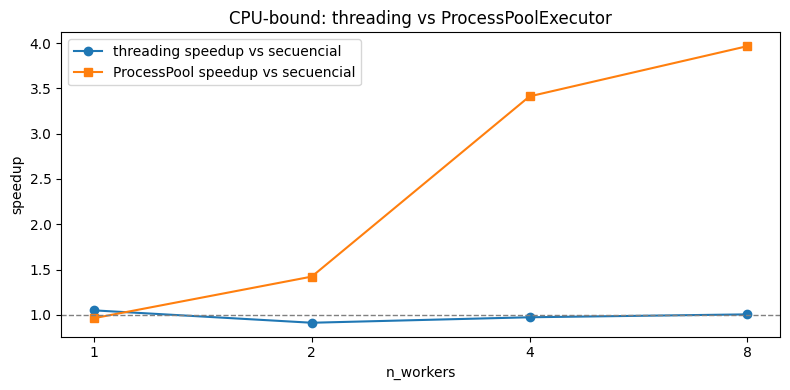

In [18]:
# IMPORTANTE: ProcessPoolExecutor requiere funciones picklables
# La función debe estar definida a nivel de módulo (no como lambda ni nested)

def tarea_cpu(n: int) -> int:
    """CPU-bound pura: wait(τᵢ) = ∅"""
    return sum(range(n))

N_TRABAJO = 20_000_000   # ajusta según tu máquina
N_WORKERS_LIST = sorted({1, 2, 4, os.cpu_count() or 1})

# --- Secuencial: baseline por número de tareas en paralelo ---
def tiempo_secuencial(n_tareas: int) -> float:
    t0 = time.perf_counter()
    for _ in range(n_tareas):
        tarea_cpu(N_TRABAJO)
    return time.perf_counter() - t0


def tiempo_threading(n_workers: int) -> float:
    hilos = []
    t0 = time.perf_counter()
    for _ in range(n_workers):
        h = threading.Thread(target=tarea_cpu, args=(N_TRABAJO,))
        hilos.append(h)
        h.start()
    for h in hilos:
        h.join()
    return time.perf_counter() - t0


def tiempo_process_pool(n_workers: int) -> float:
    t0 = time.perf_counter()
    with process_pool_executor(max_workers=n_workers) as pool:
        list(pool.map(tarea_cpu, [N_TRABAJO] * n_workers))
    return time.perf_counter() - t0


# DONE: benchmark threading vs ProcessPoolExecutor y speedup vs secuencial
speedups_thread = []
speedups_proc = []

print("n_workers | secuencial | threading | proc-pool | speedup_th | speedup_proc")
print("-" * 78)
for nw in N_WORKERS_LIST:
    t_seq = tiempo_secuencial(nw)
    t_th = tiempo_threading(nw)
    t_pp = tiempo_process_pool(nw)
    su_th = t_seq / t_th if t_th > 0 else 0
    su_pp = t_seq / t_pp if t_pp > 0 else 0
    speedups_thread.append(su_th)
    speedups_proc.append(su_pp)
    print(
        f"{nw:9d} | {t_seq:10.2f}s | {t_th:9.2f}s | {t_pp:9.2f}s | {su_th:10.2f}x | {su_pp:12.2f}x"
    )

print()
print("GIL: threading ~1× en CPU-bound; multiprocessing escala mejor (hasta #cores).")

# DONE: gráfica con matplotlib (opcional si está instalado)
try:
    import matplotlib.pyplot as plt

    xs = [str(w) for w in N_WORKERS_LIST]
    plt.figure(figsize=(8, 4))
    plt.plot(xs, speedups_thread, marker="o", label="threading speedup vs secuencial")
    plt.plot(xs, speedups_proc, marker="s", label="ProcessPool speedup vs secuencial")
    plt.axhline(1.0, color="gray", linestyle="--", linewidth=1)
    plt.xlabel("n_workers")
    plt.ylabel("speedup")
    plt.title("CPU-bound: threading vs ProcessPoolExecutor")
    plt.legend()
    plt.tight_layout()
    plt.show()
except ImportError:
    print("(matplotlib no instalado — omite la gráfica)")

## Sección 7: joblib vs ProcessPoolExecutor — misma tarea

In [20]:
try:
    from joblib import Parallel, delayed
    JOBLIB_OK = True
except ImportError:
    print("joblib no instalado — pip install joblib")
    JOBLIB_OK = False

if JOBLIB_OK:
    datos = list(range(1_000_000, 1_001_000))   # 1000 tareas
    
    # ProcessPoolExecutor
    t0 = time.perf_counter()
    with process_pool_executor(max_workers=4) as pool:
        resultados_ppe = list(pool.map(tarea_cpu, datos))
    t_ppe = time.perf_counter() - t0
    print(f"ProcessPoolExecutor (4 workers): {t_ppe:.2f}s")
    
    # joblib
    t0 = time.perf_counter()
    resultados_jl = Parallel(n_jobs=4)(delayed(tarea_cpu)(n) for n in datos)
    t_jl = time.perf_counter() - t0
    print(f"joblib.Parallel (n_jobs=4):       {t_jl:.2f}s")
    
    assert resultados_ppe == resultados_jl, "resultados diferentes!"
    print(f"\nResultados idénticos: ✓")
    print(f"\n¿Cuándo preferirías joblib sobre ProcessPoolExecutor?")
    print("Hint: considera la interfaz, integración con numpy, y el backend 'loky'")

ProcessPoolExecutor (4 workers): 2.12s
joblib.Parallel (n_jobs=4):       2.78s

Resultados idénticos: ✓

¿Cuándo preferirías joblib sobre ProcessPoolExecutor?
Hint: considera la interfaz, integración con numpy, y el backend 'loky'


## Sección 8: Anti-patrón lambda (PicklingError)

In [21]:
# TAREA 8: Reproducir el PicklingError con lambda en ProcessPoolExecutor

# Anti-patrón: lambda no puede ser serializada entre procesos
try:
    with process_pool_executor(max_workers=2) as pool:
        resultados = list(pool.map(lambda x: x**2, [1, 2, 3, 4]))
    print("¿Sin error? (puede pasar en algunos sistemas)")
    print(resultados)
except Exception as e:
    print(f"Error esperado: {type(e).__name__}: {e}")

print()

# DONE: fix con función top-level
def al_cuadrado(x: int) -> int:
    return x * x


esperado = [1, 4, 9, 16]
with process_pool_executor(max_workers=2) as pool:
    r1 = list(pool.map(al_cuadrado, [1, 2, 3, 4]))
print("Fix función nombrada:", r1, "OK" if r1 == esperado else "distinto!")

# DONE: fix con functools.partial (función picklable + argumentos fijos)
from functools import partial


def potencia(x: int, exp: int) -> int:
    return x**exp


cuadrado_partial = partial(potencia, exp=2)
with process_pool_executor(max_workers=2) as pool:
    r2 = list(pool.map(cuadrado_partial, [1, 2, 3, 4]))
print("Fix partial(potencia, exp=2):", r2, "OK" if r2 == esperado else "distinto!")

Error esperado: PicklingError: Can't pickle <function <lambda> at 0xffff872c3530>: it's not found as __main__.<lambda>

Fix función nombrada: [1, 4, 9, 16] OK
Fix partial(potencia, exp=2): [1, 4, 9, 16] OK


## Sección 9: Pool por petición vs pool compartido — medir diferencia

In [22]:
# TAREA 9: Comparar overhead de crear pool por petición vs pool compartido
# DONE: mediciones abajo (mismo trabajo; solo cambia crear vs reutilizar el pool)

N_PETICIONES = 20

# Anti-patrón: nuevo pool por petición
t0 = time.perf_counter()
for _ in range(N_PETICIONES):
    with process_pool_executor(max_workers=2) as pool:
        list(pool.map(tarea_cpu, [100_000, 100_000]))
t_pool_por_peticion = time.perf_counter() - t0
print(f"Pool por petición ({N_PETICIONES} veces): {t_pool_por_peticion:.2f}s")

# Correcto: pool compartido
t0 = time.perf_counter()
with process_pool_executor(max_workers=2) as pool_compartido:
    for _ in range(N_PETICIONES):
        list(pool_compartido.map(tarea_cpu, [100_000, 100_000]))
t_pool_compartido = time.perf_counter() - t0
print(f"Pool compartido ({N_PETICIONES} peticiones): {t_pool_compartido:.2f}s")

print(f"\nOverhead del anti-patrón: {t_pool_por_peticion/t_pool_compartido:.1f}× más lento")
print("El overhead es el costo de crear/destruir procesos N veces en lugar de una.")

Pool por petición (20 veces): 0.35s
Pool compartido (20 peticiones): 0.03s

Overhead del anti-patrón: 10.6× más lento
El overhead es el costo de crear/destruir procesos N veces en lugar de una.


## Sección 10 (opcional): run_in_executor — asyncio + ProcessPoolExecutor

Integra asyncio con ProcessPoolExecutor para manejar carga mixta (I/O + CPU).
Este es el patrón del chatbot v3 (M5b).

In [23]:
# TAREA 10: Implementar M5b — asyncio + ProcessPoolExecutor
#
# Escenario: 10 peticiones llegan simultáneamente.
# Cada petición: consulta BD (I/O, 0.1s) + inferencia LLM local (CPU, 0.5s)
#
# Compara:
#   a) Todo en asyncio con time.sleep (bloquea el event loop durante inferencia)
#   b) asyncio para I/O + run_in_executor(ProcessPoolExecutor) para CPU
#
# ¿Cuánto mejora la versión b sobre la a?
# ¿Cómo se relaciona con la Ley de Amdahl?

N_USUARIOS = 10
T_IO = 0.1    # wait(τᵢ): consulta BD
T_CPU = 0.5   # exec bloqueante: inferencia LLM

def inferencia_local(historial):
    """CPU-bound: simula inferencia del LLM local"""
    time.sleep(T_CPU)   # usa time.sleep para simular blocking CPU work
    return f"respuesta para {historial}"


# DONE: versión a — I/O async pero CPU bloquea el event loop (secuencial entre peticiones)
async def peticion_a(user_id: int) -> str:
    await asyncio.sleep(T_IO)
    historial = f"user-{user_id}"
    return inferencia_local(historial)


async def run_a() -> float:
    t0 = time.perf_counter()
    await asyncio.gather(*[peticion_a(i) for i in range(N_USUARIOS)])
    return time.perf_counter() - t0


# DONE: versión b — I/O en el loop; CPU en procesos (paraleliza inferencias)
async def run_b() -> float:
    loop = asyncio.get_running_loop()
    n_workers = min(os.cpu_count() or 2, N_USUARIOS)
    t0 = time.perf_counter()
    with process_pool_executor(max_workers=n_workers) as pool:

        async def peticion_b(user_id: int) -> str:
            await asyncio.sleep(T_IO)
            historial = f"user-{user_id}"
            return await loop.run_in_executor(pool, inferencia_local, historial)

        await asyncio.gather(*[peticion_b(i) for i in range(N_USUARIOS)])
    return time.perf_counter() - t0


t_a = await run_a()
t_b = await run_b()

print(f"Versión a (time.sleep en coroutine, bloquea el loop): {t_a:.2f}s")
print(f"Versión b (run_in_executor ProcessPool):              {t_b:.2f}s")
if t_a > 0:
    print(f"Mejora b/a: {t_a/t_b:.2f}×")

# DONE: fracción secuencial S (Amdahl) — en (a) el trabajo CPU bloquea el único hilo del event loop,
# así que las demás coroutines no avanzan durante T_CPU. En (b) el CPU corre en procesos paralelos.
print()
print(f"Por petición: I/O={T_IO}s, CPU={T_CPU}s.")
print("En (a) los T_CPU se encadenan en el mismo hilo → el tiempo total crece ~ lineal con N.")
print("En (b) varias inferencias pueden solaparse en el pool de procesos.")
print("Ley de Amdahl: la parte secuencial (aquí el bloqueo del loop en (a)) limita el speedup.")

Versión a (time.sleep en coroutine, bloquea el loop): 5.14s
Versión b (run_in_executor ProcessPool):              1.21s
Mejora b/a: 4.26×

Por petición: I/O=0.1s, CPU=0.5s.
En (a) los T_CPU se encadenan en el mismo hilo → el tiempo total crece ~ lineal con N.
En (b) varias inferencias pueden solaparse en el pool de procesos.
Ley de Amdahl: la parte secuencial (aquí el bloqueo del loop en (a)) limita el speedup.
